In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Balaji\AppData\Roaming\Python\Python312\Scripts\Selected_Features.csv")
df

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Soil_Type,Wilderness_Area,Cover_Type
0,2596,510,6279,29,1,Aspen
1,2590,390,6225,29,1,Aspen
2,2804,3180,6121,12,1,Lodgepole Pine
3,2785,3090,6211,30,1,Lodgepole Pine
4,2595,391,6172,29,1,Aspen
...,...,...,...,...,...,...
145865,2834,2552,1595,29,1,Lodgepole Pine
145866,2832,2522,1572,29,1,Lodgepole Pine
145867,2829,2492,1550,29,1,Lodgepole Pine
145868,2826,2462,1528,29,1,Lodgepole Pine


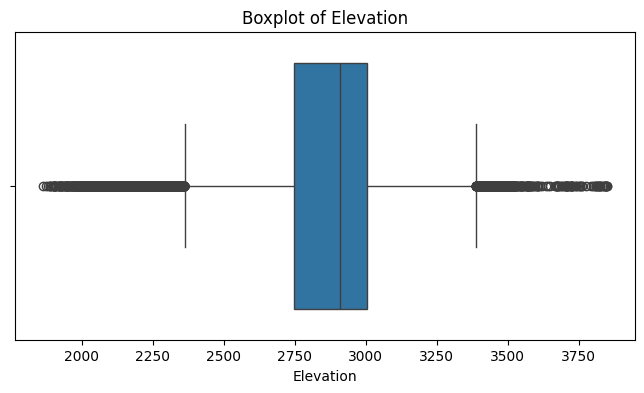

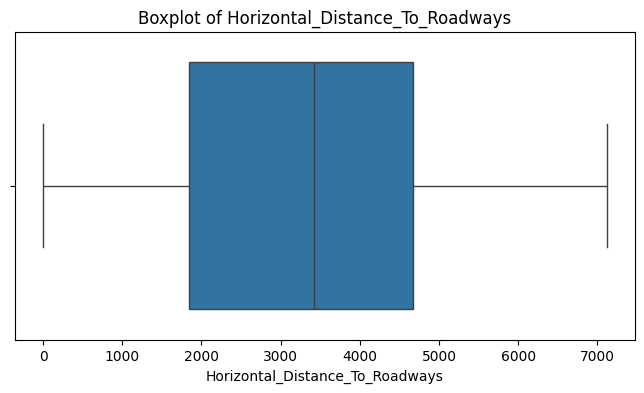

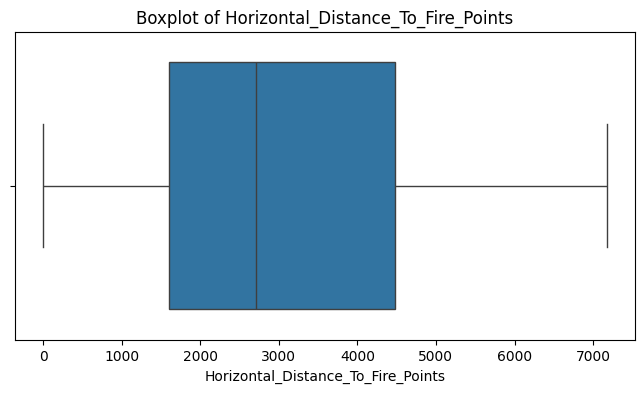

In [ ]:
# Outliers
import matplotlib.pyplot as plt
import seaborn as sns

continuous_cols = ["Elevation","Horizontal_Distance_To_Roadways","Horizontal_Distance_To_Fire_Points"]

for col in continuous_cols:
    
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [4]:
# Skewness:
for col in continuous_cols:
    print(f"{col} Skewness: {df[col].skew()}")

Elevation Skewness: -0.6647697655712669
Horizontal_Distance_To_Roadways Skewness: -0.05833583929339291
Horizontal_Distance_To_Fire_Points Skewness: 0.3653544599046248


Inference:

| Skewness Range         | Meaning                 |
| ---------------------- | ----------------------- |
| -0.5 to 0.5            | approximately symmetric |
| -1 to -0.5 or 0.5 to 1 | moderate skew           |
| < -1 or > 1            | high skew               |


Skewness analysis showed that the selected continuous features had only mild skewness and approximately stable distributions. Therefore, no additional skewness transformation techniques were required.

Detailed Inference:

Outlier & Skewness Treatment Decision:
-----------------------------------------------------------------------------------------------------------------------------------------------
Why Kurtosis Analysis Was Not Performed:
Kurtosis mainly measures:

Tail heaviness,extreme peak behavior and the concentration of values around the mean.

Although kurtosis can provide additional statistical insight, it is more commonly used in advanced statistical analysis and distribution research rather than standard tabular machine learning preprocessing workflows.
Since:

The dataset did not exhibit severe skewness,outliers were limited and mostly represented valid environmental variations and model performance remained strong without additional normalization.

During the data cleaning and transformation stage, outlier analysis was performed on continuous numerical features using boxplots and skewness analysis. The selected continuous features were:

Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points

Categorical variables such as Soil_Type, Wilderness_Area, and the target variable Cover_Type were excluded from outlier analysis because they represent encoded category labels rather than measurable continuous numerical values.

Why Outliers Were Not Removed
-----------------------------------------------------------------------------------------------------------------------------------------------
Although mild outliers were observed mainly in the Elevation feature, they were not removed because this dataset represents real-world environmental and geographical measurements. Extreme elevation values may naturally occur in mountainous or uneven terrains and therefore can contain meaningful predictive information rather than data errors.
Removing such observations could lead to:

loss of important environmental patterns,reduced model generalization and information loss from naturally occurring geographical variations.

Additionally, tree-based models such as Random Forest and XGBoost are generally robust to moderate outliers, reducing the necessity for aggressive outlier removal.

Why IQR Capping Was Not Applied
----------------------------------------------------------------------------------------------------------------------
IQR-based capping is useful when extreme values are unrealistic or highly influential. However, in this dataset:
The detected outliers were limited,no severe abnormal spikes were observed and the continuous features showed relatively stable distributions.

Since the identified extreme values appeared to be genuine geographical observations rather than noise or data-entry errors, IQR capping was avoided to preserve original environmental information.

Why Log Transformation Was Not Applied:
-----------------------------------------------------------------------------------------------------
Skewness analysis was performed using:
df[col].skew()
1) The obtained skewness values were within acceptable limits:
2) FeatureSkewnessElevation - 0.66 Horizontal_Distance_To_Roadways - 0.05 Horizontal_Distance_To_Fire_Points - 0.36
3) Since all skewness values were within the moderate range:
   abs(skewness) < 1
4) the distributions were considered reasonably balanced. Therefore, additional transformations such as log1p() were unnecessary.
5) Applying log transformation without significant skewness could unnecessarily distort the original feature distributions.

Why Yeo-Johnson and Box-Cox Transformations Were Not Used
-----------------------------------------------------------------------------------------------
Advanced transformation techniques such as Yeo-Johnson and Box-Cox are generally used when:

1) features exhibit severe skewness,
2) distributions are highly non-normal,or strong normalization is required.

In this project:
----------------------------------------------------------------------------------
The continuous variables showed only mild skewness,the dataset was already relatively stable and baseline model performance was strong without complex transformations.

Therefore, applying advanced transformations would add unnecessary preprocessing complexity without providing significant modeling benefits.

Final Conclusion:
-----------------------------------------------------------------------------------
After performing outlier and skewness analysis, it was concluded that the dataset did not contain severe distributional issues requiring aggressive preprocessing. Therefore, the original continuous feature distributions were retained to preserve meaningful environmental and geographical information while maintaining model interpretability and stability.

Feature Engineering and Encoding:
------------------------------------------------------------------------------------------------------------------------------------------
Inference:

The selected features already achieved a strong baseline model accuracy of above 95%. Therefore, additional derived feature creation was not considered necessary, as the existing geographical and environmental features already provided strong predictive performance.

Encoding Strategy:

The target variable Cover_Type was encoded using LabelEncoder because machine learning classification models require numerical class labels.

The categorical features Soil_Type and Wilderness_Area were transformed using One-Hot Encoding before model training.

Although these features were already represented using integer labels, those values represented categorical identifiers rather than continuous numerical quantities. Using the original integer encoding could introduce unintended ordinal relationships and bias certain machine learning models such as Logistic Regression and K-Nearest Neighbors (KNN).

Therefore, One-Hot Encoding was applied to ensure that the categorical features were represented without implying any numerical order or magnitude relationship between categories.

The encoders were saved using joblib/pickle to ensure consistency between training and inference during deployment.

Note: Since we are plainning to use the one hot encoding for soil_type and wilderness area it will increase features and difficult for performing EDA

So we are following this flow now EDA-->Encoding-->Train test split-->Class Imbalance handling-->Model building-->Evluation-->Hyperparametric Tuning-->Evluation-->Streamlit app


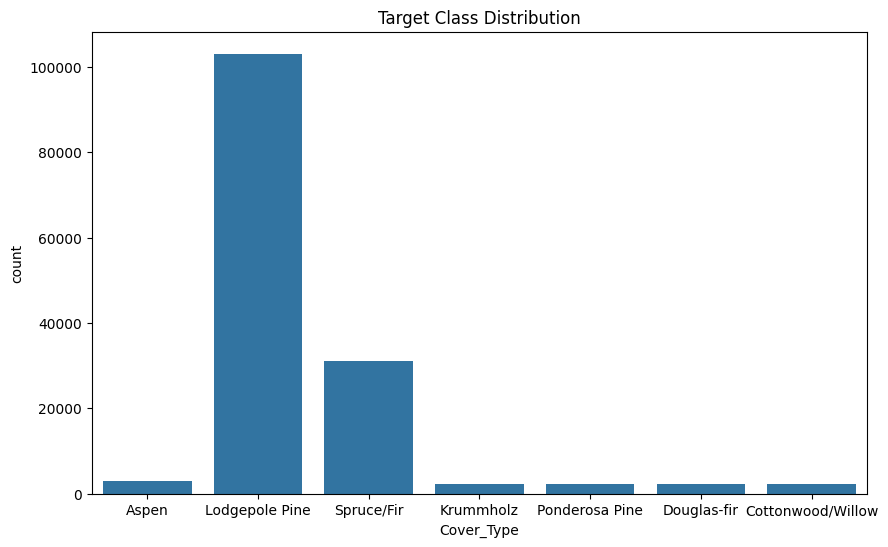

In [ ]:
#EDA:
# 1) Target Class Distribution:
plt.figure(figsize=[10,6])
plt.title("Target Class Distribution")
sns.countplot(x="Cover_Type", data=df)
plt.show()

Inference:
1) The dataset shows severe class imbalance with two highly dominant categories.
2) Lodgepole Pine is the most frequent category, exceeding one hundred thousand.
3) Five minority classes have extremely low counts compared to the rest.

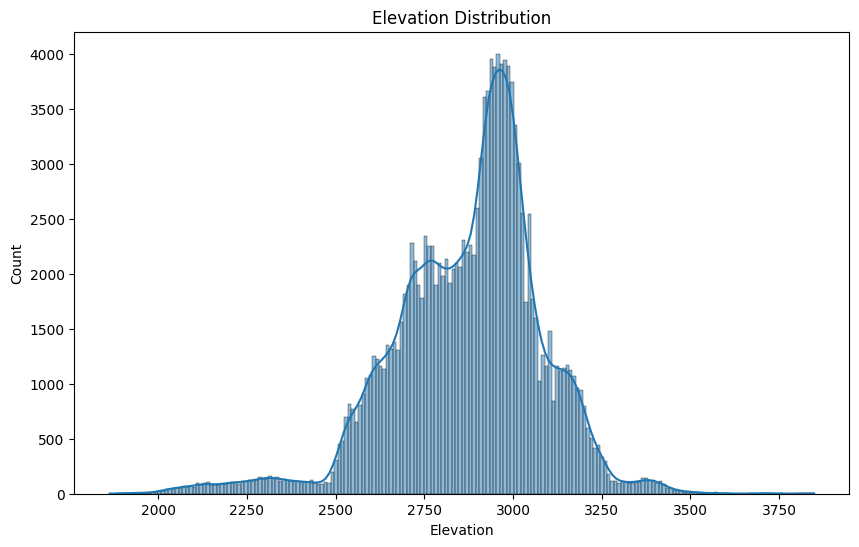

In [ ]:
# 2) Elevation Distribution:
plt.figure(figsize=[10,6])
plt.title("Elevation Distribution")
sns.histplot(df["Elevation"], kde=True)
plt.show()

Inference:
1) The elevation data follows a multi-peaked, roughly bell-shaped distribution pattern.
2) Most observations are concentrated between twenty-five hundred and thirty-two hundred.
3) The highest peak or mode occurs right around three thousand elevation.

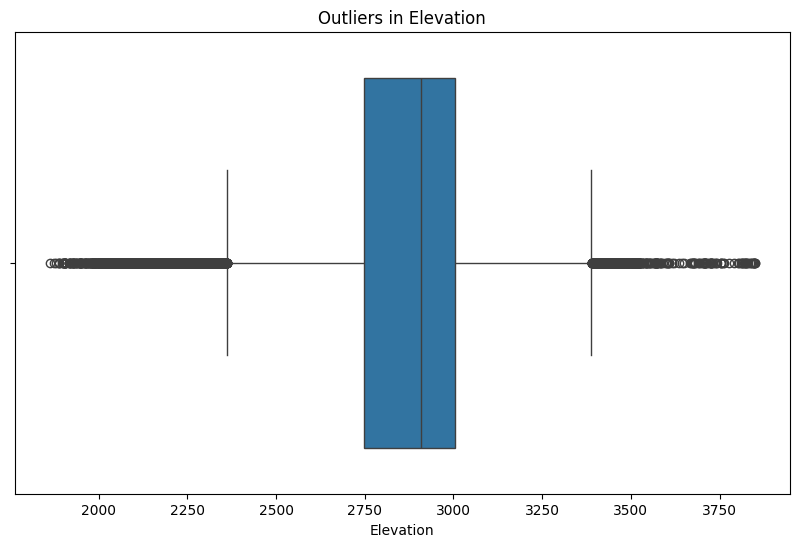

In [10]:
# 3) Elevation Boxplot
plt.figure(figsize=[10,6])
plt.title("Outliers in Elevation")
sns.boxplot(x=df["Elevation"]) 
plt.show()

Inference:

1) Terrain Reality: Outliers represent real-world mountain peaks and valleys, not data errors.
2) Left Skewness: Negative skewness shows a longer tail toward lower elevation areas.
3) Core Distribution: The middle fifty percent of data lies between twenty-seven fifty and three thousand.
4) No Capping: IQR capping was avoided to preserve original geographical patterns.
5) Model Compatibility: Tree-based algorithms naturally handle these dense elevation outliers effectively.

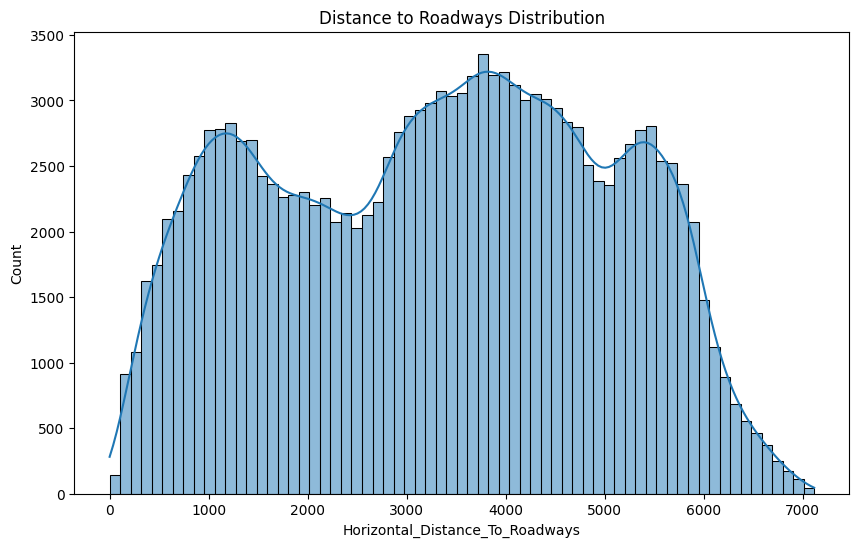

In [11]:
# 4) Distance to Roadways Distribution:
plt.figure(figsize=[10,6])
plt.title("Distance to Roadways Distribution")
sns.histplot(df["Horizontal_Distance_To_Roadways"], kde=True)
plt.show()

Inference:
1) Distribution Shape: Multi-peaked, balanced distribution with an excellent skewness score of -0.058.
2) Outlier Decision: No capping applied because fluctuations represent real-world road networks, not errors.


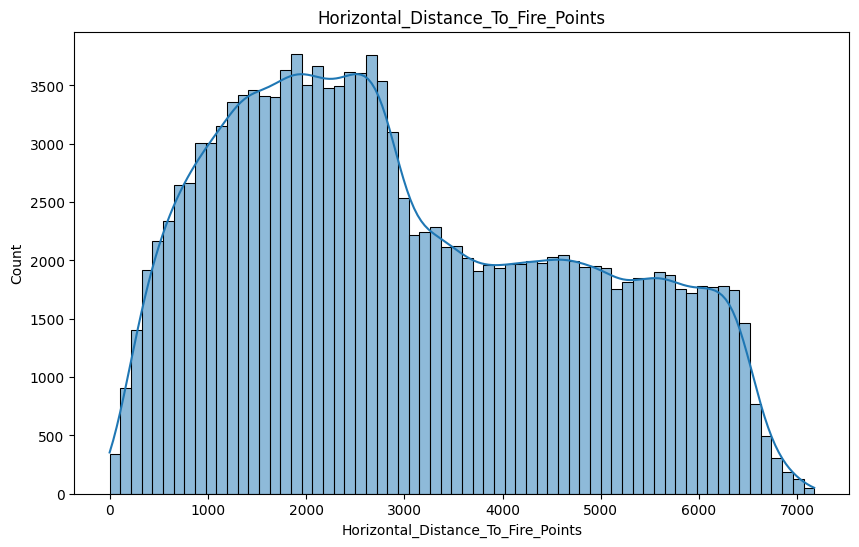

In [12]:
# 5) Distance To Fire Points Distribution:
plt.figure(figsize=[10,6])
plt.title("Horizontal_Distance_To_Fire_Points")
sns.histplot(df["Horizontal_Distance_To_Fire_Points"], kde=True)
plt.show()

Inference:
1) Distribution Shape: Mildly right-skewed distribution (skewness = 0.365) with two broad data clusters.
2) Outlier Decision: No transformation needed since the score falls safely within acceptable statistical limits.

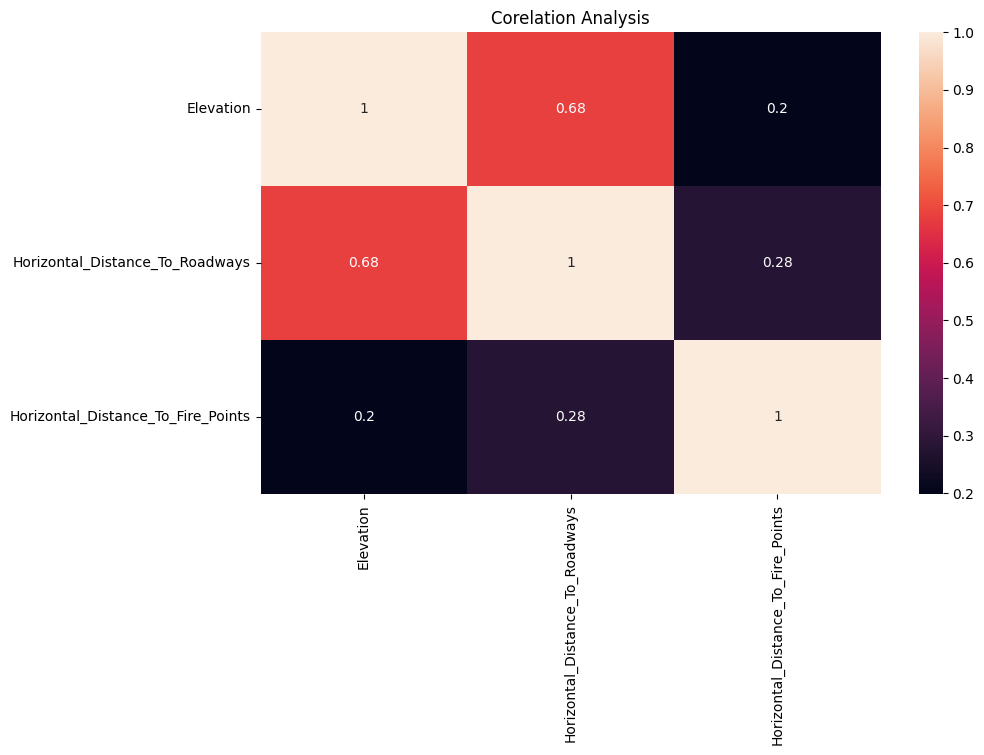

In [13]:
# Correlation Heatmap
plt.figure(figsize=[10,6])
plt.title("Corelation Analysis")
sns.heatmap(df[continuous_cols].corr(), annot=True)
plt.show()

Insights:
1) Strongest Feature Relationship: Elevation and horizontal distance to roadways share a moderately strong positive correlation of point sixty-eight.
2) Weakest Linear Relationship: Elevation and distance to fire points have the weakest correlation at exactly point twenty
3) No Multicollinearity Issues: All correlation values sit below point seven, meaning features can be safely used without multicollinearity concerns.

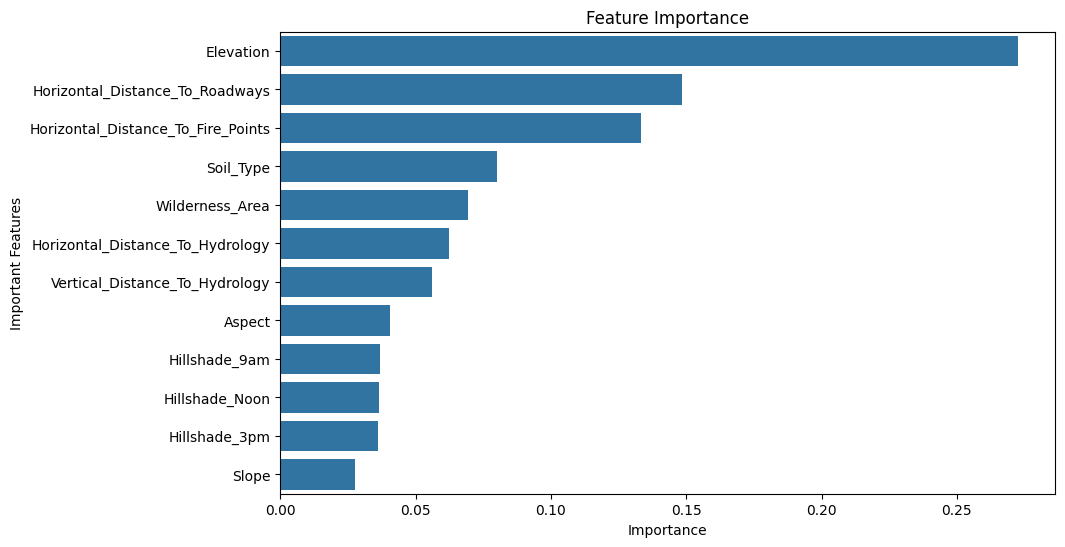

In [21]:
# 7) Feature Importance:
df1 = pd.read_csv(r"C:\Users\Balaji\AppData\Roaming\Python\Python312\Scripts\Features.csv")
df1.rename(columns={"Important Feturures":"Important Features"},inplace=True)
df1
plt.figure(figsize=[10,6])
plt.title("Feature Importance")
sns.barplot(data=df1,x="Importance",y="Important Features")
plt.show()

Inference:
1) Primary Predictor: Elevation stands out clearly as the single most critical feature for model predictions.
2) Key Distance Factors: Proximity parameters to roadways and fire points hold the next highest importance scores.
3) Top Categorical Variables: Soil type and wilderness area act as the most influential non-numerical predictive factors.
4) Hydrology Impact: Horizontal water distance proves more valuable to the model than vertical water distance.
5) Least Influential Feature: Slope contributes the absolute lowest amount of predictive power among all listed features.

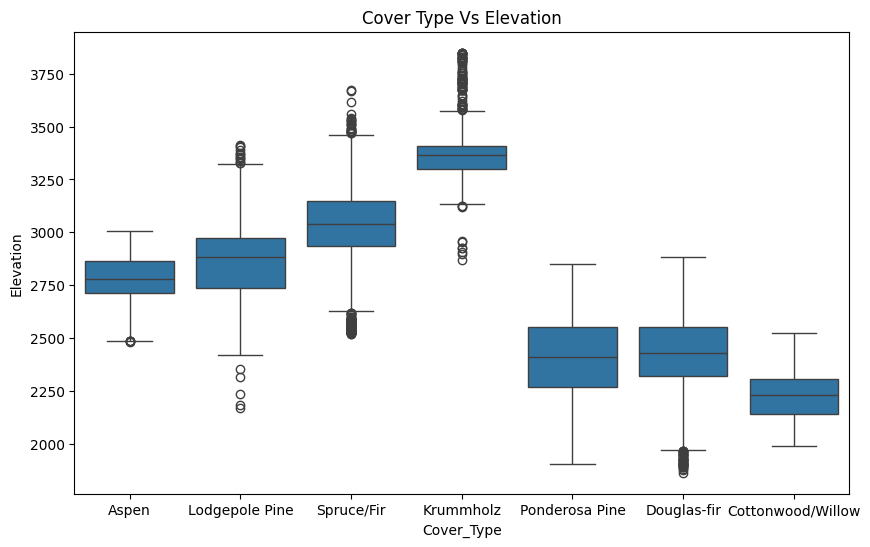

In [22]:
# 8) Cover Type vs Elevation:
plt.figure(figsize=[10,6])
plt.title("Cover Type Vs Elevation")
sns.boxplot(x="Cover_Type",y="Elevation",data=df)
plt.show()

Inference:
The boxplot analysis showed elevation differences across forest cover types, with certain classes such as Krummholz occurring at higher elevations. Although some outlier observations were present, they appeared to represent valid environmental and geographical variations rather than data anomalies. Therefore, no aggressive outlier treatment was applied.

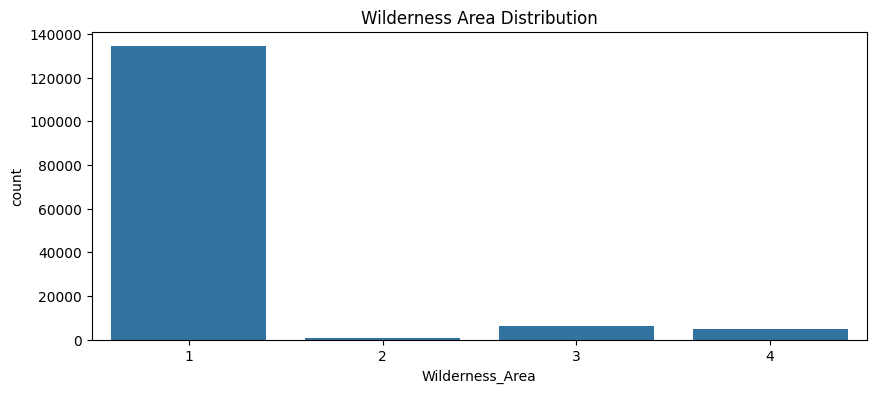

In [26]:
# 9) Wilderness Area Distribution:
plt.figure(figsize=[10,4])
plt.title("Wilderness Area Distribution")
sns.countplot(x="Wilderness_Area", data=df)
plt.show()

Inference:
Wilderness Area 1 dominates the dataset, indicating strong geographical imbalance and potential environmental influence on forest cover distribution.

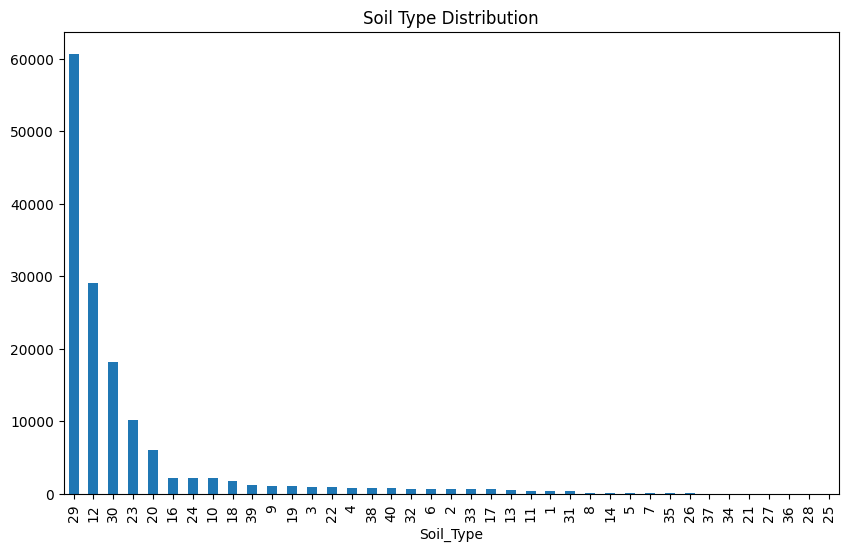

In [29]:
# 10) Soil Type Distribution:

plt.figure(figsize=[10,6])
plt.title("Soil Type Distribution")
df["Soil_Type"].value_counts().plot(kind="bar")
plt.show()

Inference:
1) Massive Overrepresentation: Soil Type twenty-nine is clearly the most dominant category across the entire dataset
2) Exponential Drop-off: The counts decrease drastically and rapidly across the top five highest categories
3) Extreme Sparsity: A massive majority of individual soil types have almost zero presence here.

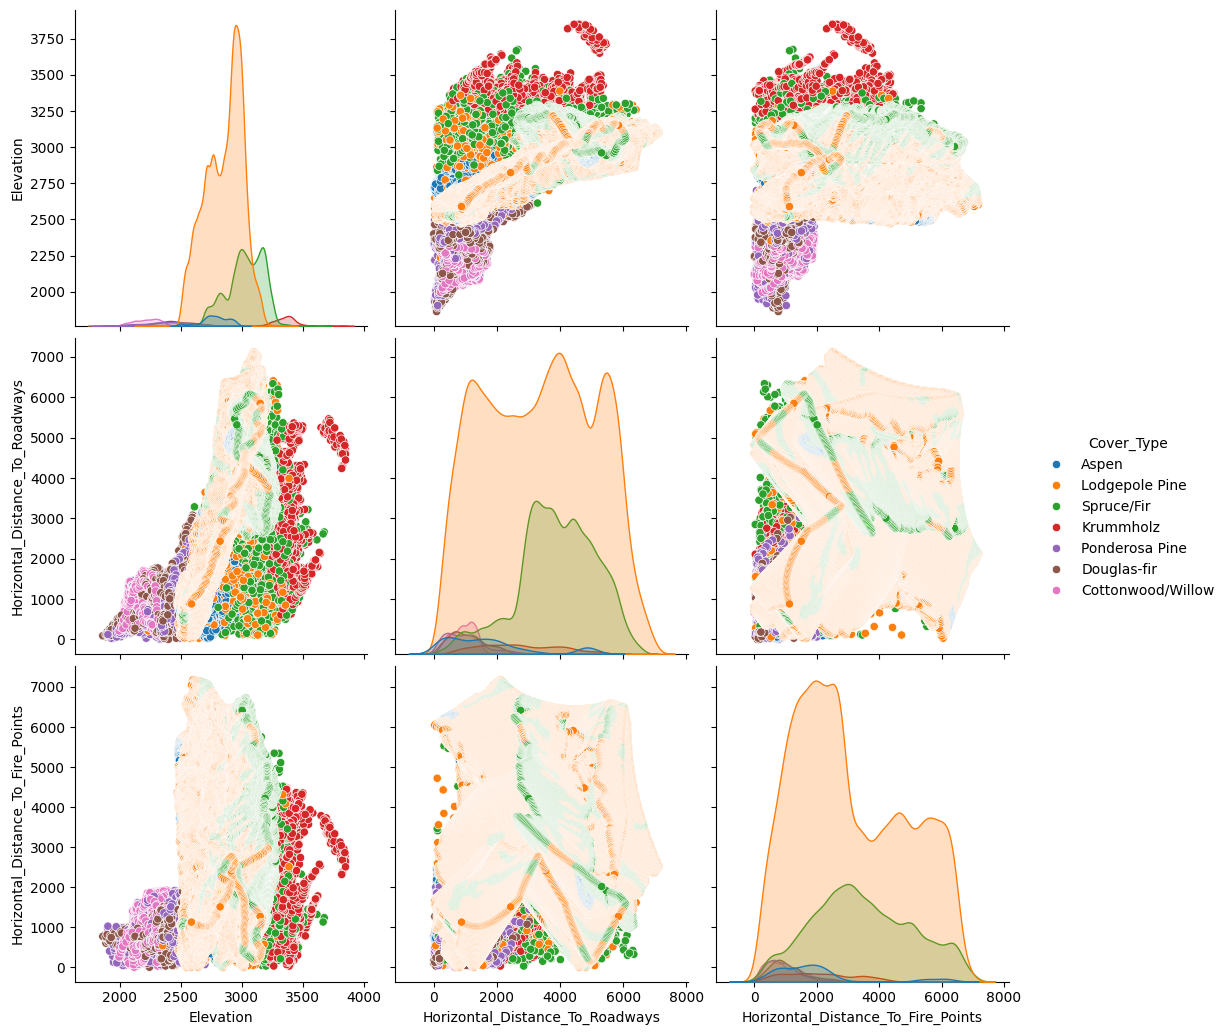

In [36]:
# 11) Pairplot:

sns.pairplot(df[["Elevation","Horizontal_Distance_To_Roadways","Horizontal_Distance_To_Fire_Points","Cover_Type"]],hue="Cover_Type",height=3.5,palette="tab10")


Usage:

1) Visualizes All Combinations: It plots pairwise relationships across all numerical variables in one single grid.
2) Identifies Class Separation: Using hue helps detect how distinctly different target classes cluster together.
3) Shows Feature Distributions: The diagonal plots display the individual distribution shape for each specific feature.

Inference:

1) Clear Elevation Segregation: Target classes show distinct structural grouping along different altitudinal zones.
2) Krummholz Elevation Dominance: The Krummholz class occupies the highest elevation ranges exclusively.
3) Severe Class Imbalance: Lodgepole Pine heavily overlaps and dominates almost all feature combinations.
4) Low Altitude Clusters: Cottonwood and Douglas-fir categories cluster tightly at lower elevation levels.
5) Distance Feature Overlap: Horizontal distances to roadways and fire points exhibit high feature overlap.